In [29]:
import numpy as np
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

Forming dataset

In [30]:
x,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=1.0)

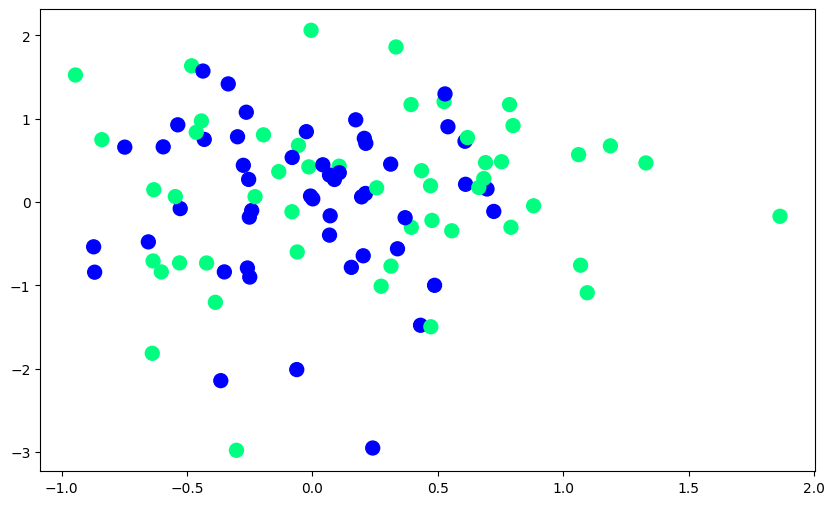

In [31]:
plt.figure(figsize=(10,6))
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)

perceptor method

In [32]:
def percepton(x,y):
    x=np.insert(x,0,1,axis=1)
    weights=np.ones(x.shape[1])
    lr=0.1
    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(x[j],weights)) #we are making a step function here
        weights=weights+lr*(y[j]-y_hat)*x[j]
    return weights[0],weights[1:]

In [33]:
def step(z):
    return 1 if z>0 else 0

In [34]:
intercept_,coef_=percepton(x,y)
print(coef_)
print(intercept_)

[0.07780997 0.10014968]
-0.09999999999999987


In [35]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [36]:
x_input1=np.linspace(-3,3,100)
y_input1=m*x_input1+b

(-3.0, 2.0)

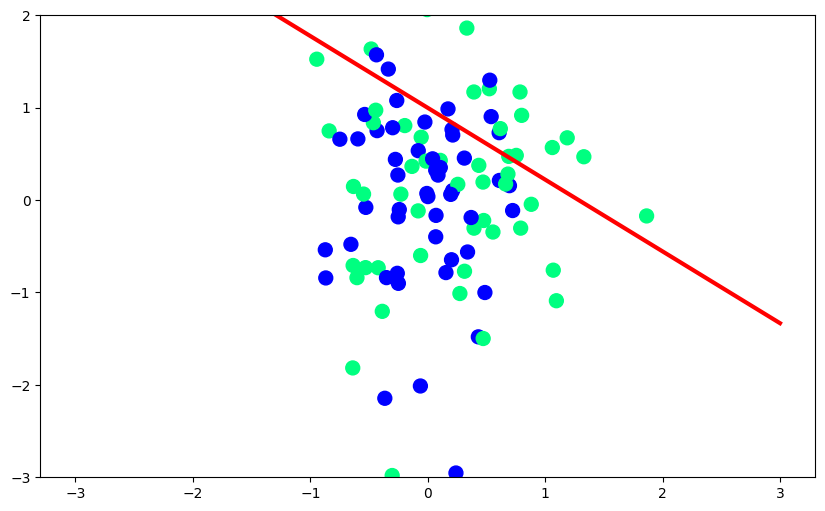

In [37]:
plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='red',linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

Sklearn logistic regression class

In [38]:
lor=LogisticRegression()
lor.fit(x,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_[0]/lor.coef_[0][1])

In [40]:
x_input2 = np.linspace(-3,3,100)
y_input2= m*x_input2 + b

(-3.0, 2.0)

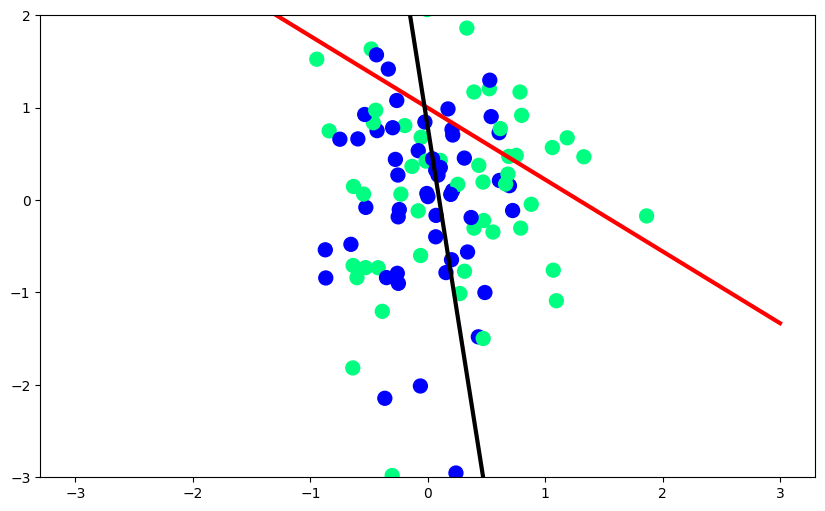

In [41]:
plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='red',linewidth=3)
plt.plot(x_input2,y_input2,color='black',linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

sklearn's method is better than percepton because it classifies data more symmetrically while percepton just classifies data and doesnot try to improve the classification line

Sigmoid Function

In [42]:
def percepton(x,y):
    x=np.insert(x,0,1,axis=1)
    weights=np.ones(x.shape[1])
    lr=0.1
    for i in range(1000):
        j=np.random.randint(0,100)
        z=np.dot(x[j],weights)
        y_hat=sigmoid(z)
        weights = weights + lr * (y[j] - y_hat) * x[j]
    return weights[0],weights[1:]

In [43]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [44]:
intercept_,coef_=percepton(x,y)

In [45]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])
print(coef_)
print(intercept_)

[0.77956272 0.26920408]
0.2643071736217867


In [46]:
x_input3 = np.linspace(-3,3,100)
y_input3= m*x_input3 + b

(-3.0, 2.0)

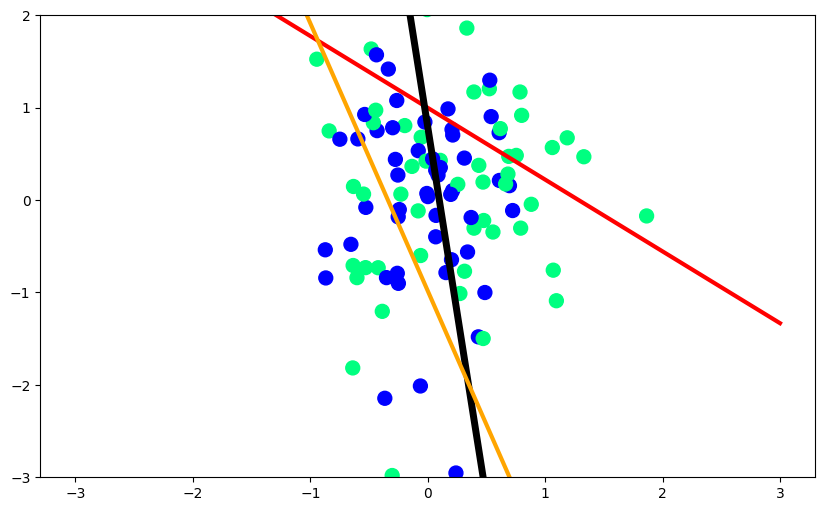

In [47]:
plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='red',linewidth=3)
plt.plot(x_input2,y_input2,color='black',linewidth=5)
plt.plot(x_input3,y_input3,color='orange',linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

Gradient Descent

In [48]:
def gd(x,y):
    x=np.insert(x,0,1,axis=1)
    weights=np.ones(x.shape[1])
    lr=0.1
    for i in range(1000):
        z=np.dot(x,weights)
        y_hat=sigmoid(z)
        weights = weights + lr * np.dot((y - y_hat),x)/x.shape[0]
    return weights[0],weights[1:]    

In [49]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [50]:
intercept_,coef_=gd(x,y)

In [51]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [52]:
x_input4= np.linspace(-3,3,100)
y_input4= m*x_input4 + b

(-3.0, 2.0)

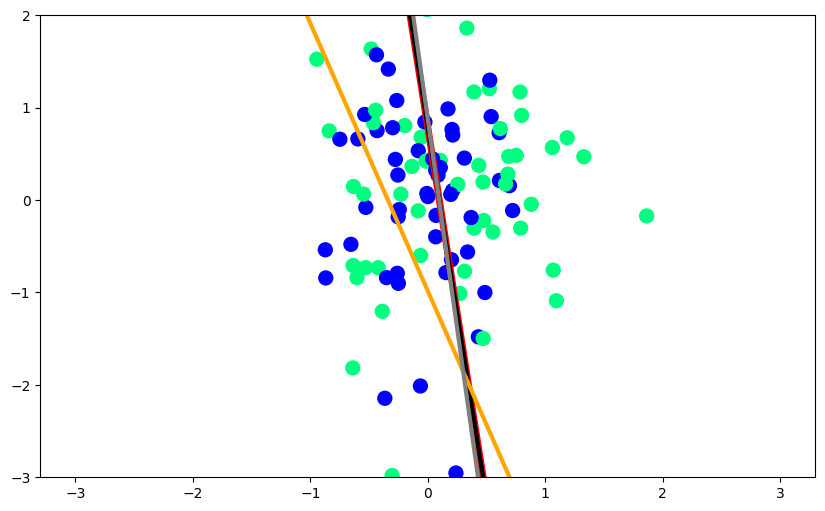

In [53]:
plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input2,color='red',linewidth=5) #perceptor
plt.plot(x_input2,y_input2,color='black',linewidth=3)  # sk learn logistic reg 
plt.plot(x_input3,y_input3,color='orange',linewidth=3) # Sigmoid 
plt.plot(x_input4,y_input4,color='grey',linewidth=3) # gradient descent
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)